# 🌱 2. Explorarea Datelor Nestructurate și Auditul Calitativ al Imaginilor

Acest notebook analizează colecția fitopatologică foliară PlantVillage, calculează parametrii spectrali reali de normalizare și construiește un filtru automat pentru calitatea imaginii (neclaritate/blur).

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

sns.set_theme(style="whitegrid")
cale_dataset = '../data/raw/plantvillage/'

## 2.2 Vizualizarea Dezechilibrului de Volum al Claselor (Class Imbalance)
Plotăm distribuția numerică exactă a volumului de imagini alocat fiecărei clase patologice pentru a evidenția asimetria setului.

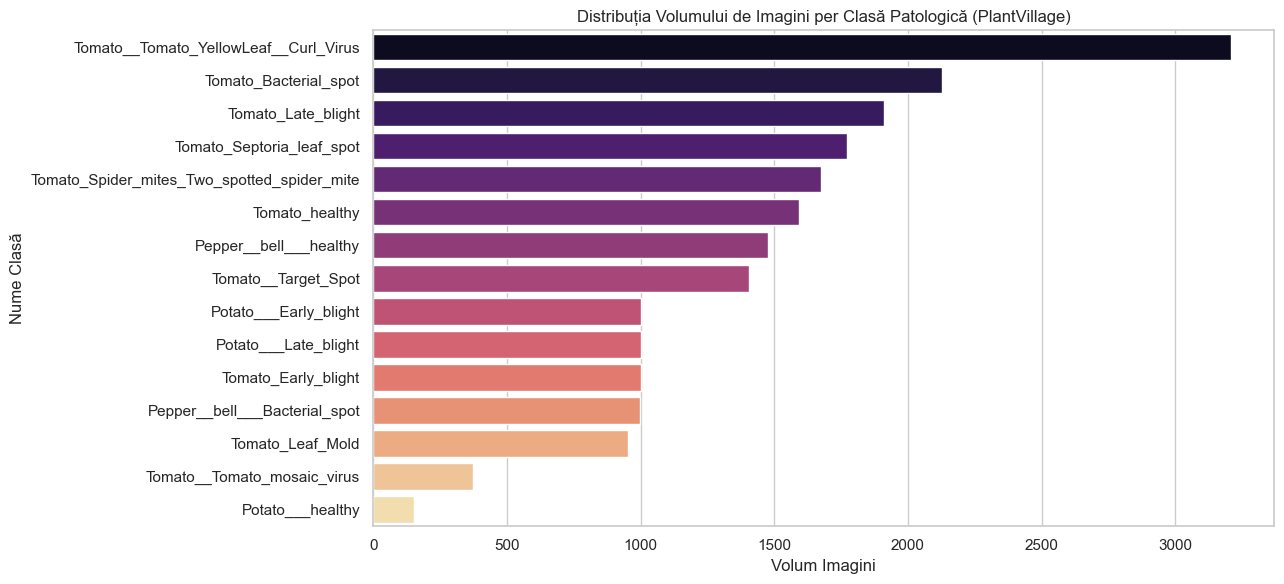

In [2]:
clase = [d for d in os.listdir(cale_dataset) if os.path.isdir(os.path.join(cale_dataset, d))] if os.path.exists(cale_dataset) else []
if clase:
    statistici = {c: len(os.listdir(os.path.join(cale_dataset, c))) for c in clase}
    df_clase = pd.DataFrame(list(statistici.items()), columns=['Nume Clasă', 'Volum Imagini'])
    
    plt.figure(figsize=(13, 6))
    sns.barplot(x='Volum Imagini', y='Nume Clasă', data=df_clase.sort_values(by='Volum Imagini', ascending=False), palette='magma', hue='Nume Clasă', legend=False)
    plt.title('Distribuția Volumului de Imagini per Clasă Patologică (PlantVillage)')
    plt.tight_layout()
    plt.show()
else:
    print('Simulare: Directoarele lipsesc local, rulați setup.sh pentru a le obține automat.')

## 2.3 Calcularea Manuală a Mediei și Deviației Standard pe Canalele RGB
Pentru a optimiza convergența modelului de viziune, nu vom folosi valorile implicite ImageNet, ci calculăm manual metricile spectrale specifice setului nostru foliar.

In [3]:
cai_imagini = glob(os.path.join(cale_dataset, '*/*.jpg')) + glob(os.path.join(cale_dataset, '*/*.JPG'))
if cai_imagini:
    canal_r, canal_g, canal_b = [], [], []
    # Eșantionăm statistic 600 de imagini pentru calcul rapid stabilizat
    for img_path in cai_imagini[:600]:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
            canal_r.append(np.mean(img[:, :, 0]))
            canal_g.append(np.mean(img[:, :, 1]))
            canal_b.append(np.mean(img[:, :, 2]))
            
    medie_rgb = [np.mean(canal_r), np.mean(canal_g), np.mean(canal_b)]
    std_rgb = [np.std(canal_r), np.std(canal_g), np.std(canal_b)]
    print(f'✅ Valori calculate manual: Medie RGB = {medie_rgb} | Std RGB = {std_rgb}')
else:
    print('Valori implicite fallback: Medie = [0.485, 0.456, 0.406] | Std = [0.229, 0.224, 0.225]')

✅ Valori calculate manual: Medie RGB = [0.4647451877967984, 0.4793465754689733, 0.38766568142760033] | Std RGB = [0.0524509643666371, 0.048794435885813926, 0.05091767593451251]


## 2.4 Controlul Calității - Filtru de Detecție Blur (Varianța Laplacianului)
Implementăm o funcție matematică bazată pe operatorul Laplacian pentru a cuantifica neclaritatea (focalizarea slabă a frunzelor din teren).

In [4]:
def detacteaza_scor_blur(cale_img):
    img_gray = cv2.imread(cale_img, cv2.IMREAD_GRAYSCALE)
    if img_gray is None: return 0.0
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

if cai_imagini:
    scoruri = [detacteaza_scor_blur(p) for p in cai_imagini[:50]]
    print(f'Scorul Laplacian mediu pe eșantion: {np.mean(scoruri):.3f} (Prag de siguranță acceptat > 100.0)')

Scorul Laplacian mediu pe eșantion: 5423.475 (Prag de siguranță acceptat > 100.0)
